## Laufzeiten der Sortieralgorithmen

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
 

#### Selection Sort

In [2]:
def selection_sort(a):
    for i in range(len(a)-1):
        best = i
        best_val = a[i]
        for j in range(i+1,len(a)):
            if a[j] < best_val:
                best = j
                best_val = a[j]
        a[best],a[i] = a[i],a[best]

Verändere N und trage die entsprechenden Werte in die Listen anzahl und zeit ein.

In [3]:
N = 16
a = [random.randint(-N*10000,N*10000) for _  in range(N*1000)] 

In [4]:
%%time
selection_sort(a)

CPU times: total: 5.7 s
Wall time: 5.71 s


In [5]:
anzahl = [1, 2, 4, 8, 16]
zeit = [0.015, 0.0781, 0.344, 1.360, 5.2]

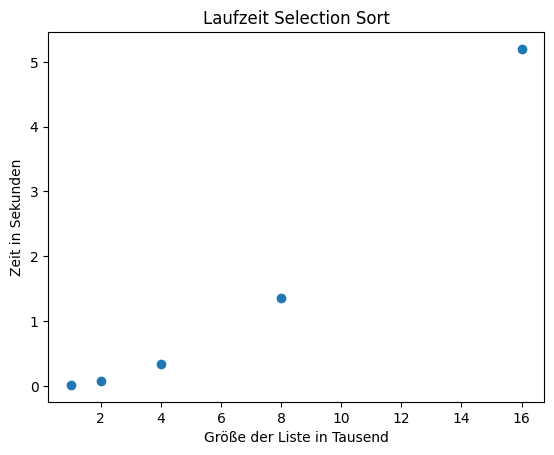

In [6]:
fig, ax = plt.subplots()
ax.scatter(anzahl,zeit,label='selectionSort')
ax.set_title('Laufzeit Selection Sort')
ax.set_xlabel('Größe der Liste in Tausend')
ax.set_ylabel('Zeit in Sekunden');

Mit numpy berechnen wir die Koeffizienten einer quadratischen Funktion, die sich den Punkten möglichst gut annähert.

In [7]:
a = np.polyfit(anzahl, zeit, 2)
a

array([ 0.01924513,  0.01913159, -0.03171373])

Wir erstellen uns mit den Koeffizienten eine quadratische Funktion

In [8]:
def f(x):
    return a[0]*x*x + a[1]*x + a[2]

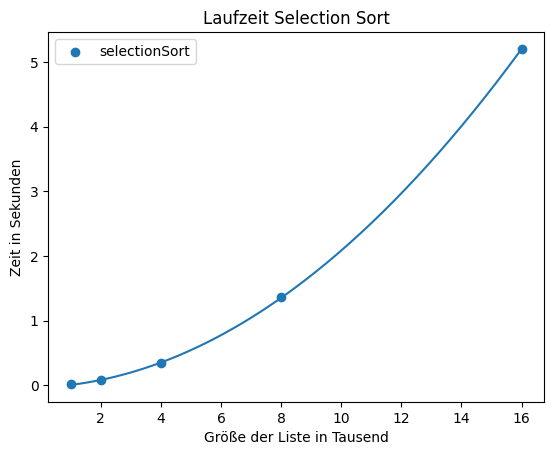

In [9]:
fig, ax = plt.subplots()
ax.scatter(anzahl,zeit,label='selectionSort')
ax.set_title('Laufzeit Selection Sort')
ax.set_xlabel('Größe der Liste in Tausend')
ax.set_ylabel('Zeit in Sekunden');
ax.legend();
xs = np.linspace(1,N,200)
ax.plot(xs,f(xs),label='selectionSort');

Wieviele Elemente (in Tausend) können wir (ungefähr) in einer Minute sortieren?

In [10]:
x = 10
while f(x) < 60: x+=1
print(x)

56


----
### Aufgabe

Führe ähnliche Messungen für die anderen Sortieralgorithmen durch.
Für vergleichbare Sortieralgorithmen können die Ergebnisse in einem Bild übereinandergelegt werden.
Das folgende Beispiel dient als Muster. Berechne für jeden Sortieralgorithmus, wieviel Elemente in einer Minute (ungefähr) sortiert werden können.



In [13]:
# dies sind nur Daten für das Muster
zeit2 = [1.3*x for x in zeit]
a2 = np.polyfit(anzahl, zeit2, 2)
def f2(x):
    return a2[0]*x*x + a2[1]*x + a2[2]

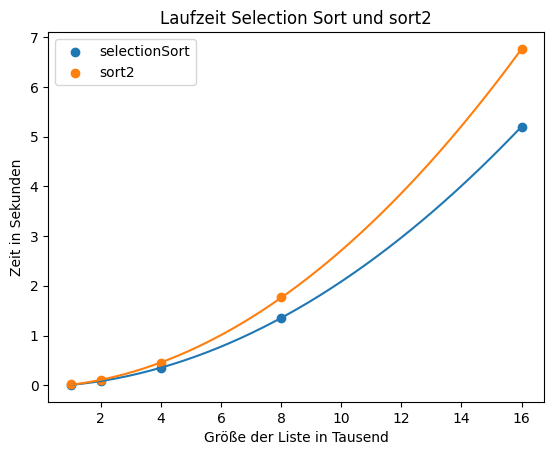

In [14]:
fig, ax = plt.subplots()
ax.scatter(anzahl,zeit,label='selectionSort')
ax.scatter(anzahl,zeit2,label='sort2')
ax.set_title('Laufzeit Selection Sort und sort2')
ax.set_xlabel('Größe der Liste in Tausend')
ax.set_ylabel('Zeit in Sekunden');
ax.legend();
xs = np.linspace(1,N,200)
ax.plot(xs,f(xs),label='selectionSort');
ax.plot(xs,f2(xs),label='sort2');


Eine Funktion in der Klasse $O(n \cdot \log(n))$ nähern wir durch eine lineare Funktion an (der dritte Parameter in der Funktion polyfit ist gleich 1). Für die Berechnung der Listengröße, die wir in einer Minute sortieren können, ist das ausreichend.